# Entropy values for tissue samples

##### Modules

In [1]:
import os
import pandas as pd
import numpy as np
import itertools
import math

import upsetplot
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors

##### Fonts & Colors

In [2]:
# font style
locations = ['/home/eger/software/fonts']
font_files = font_manager.findSystemFonts(fontpaths = locations)
for file in font_files:
    font_manager.fontManager.addfont(file)
plt.rcParams['font.family'] = 'Aptos'

# font size
b = 1
title_size = 18 + b
label_size = 16 + b
tick_size = 12 + b

##### Inputs

In [3]:
DIR1 = '/scratch/eger/projects/MethSmoothEval/tissues/modkit/entropy'

fname1 = os.path.join(DIR1, 'All_entropy_nonmiss.tsv') # 3915791
df1 = pd.read_csv(fname1, sep='\t').dropna()

### Distribution per sample

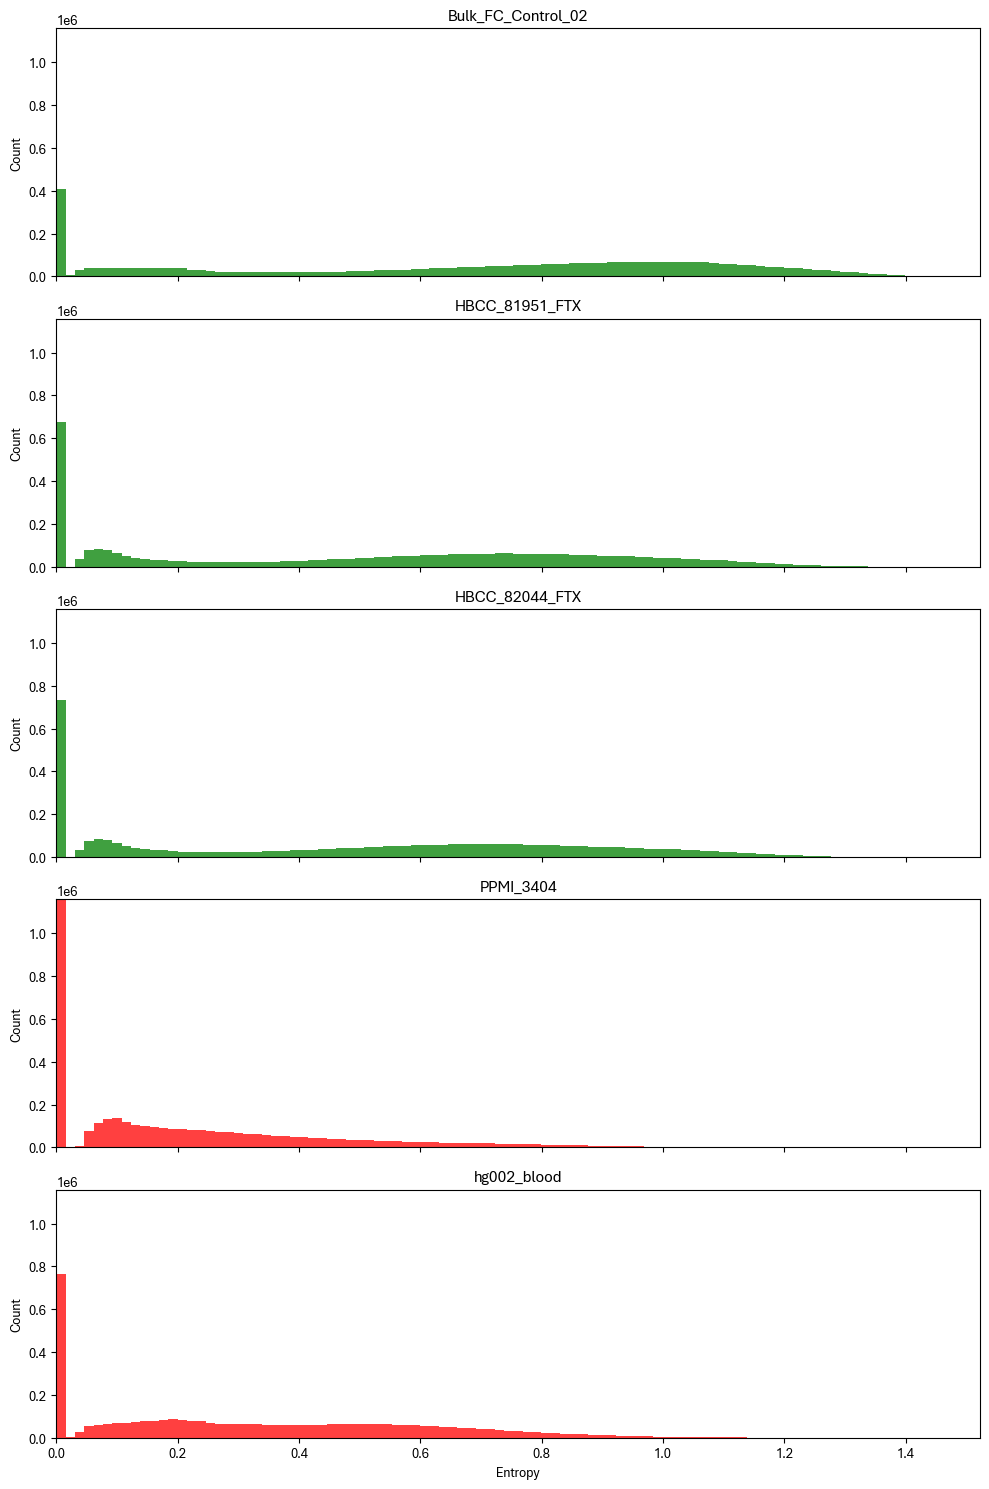

In [13]:
# Columns
brain_cols = df1.columns[3:6]   # first 3 samples
blood_cols = df1.columns[6:8]   # last 2 samples
all_cols = list(brain_cols) + list(blood_cols)

# Colors
colors = {col: "green" for col in brain_cols}
colors.update({col: "red" for col in blood_cols})

# Compute global x-axis limits
all_values = df1[all_cols].values.flatten()
xmin, xmax = np.nanmin(all_values), np.nanmax(all_values)

# Define bins globally so all histograms align
bins = np.linspace(xmin, xmax, 100)

# Compute global y-axis max
ymax = 0
hist_data = {}

for col in all_cols:
    vals = df1[col].dropna()
    counts, _ = np.histogram(vals, bins=bins)
    ymax = max(ymax, counts.max())
    hist_data[col] = vals

# Plot
fig, axes = plt.subplots(len(all_cols), 1, figsize=(10, 15), sharex=True, sharey=True)

quantiles = [0.25, 0.5, 0.75]

for ax, col in zip(axes, all_cols):
    vals = hist_data[col]
    
    sns.histplot(vals, bins=bins, ax=ax, color=colors[col], edgecolor=None)
    
    #ax.set_yscale('log')
    ax.set_title(col)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, ymax)

# Labels
axes[0].set_ylabel("Count")
for ax in axes:
    ax.set_xlabel("Entropy")

plt.tight_layout()
plt.show()

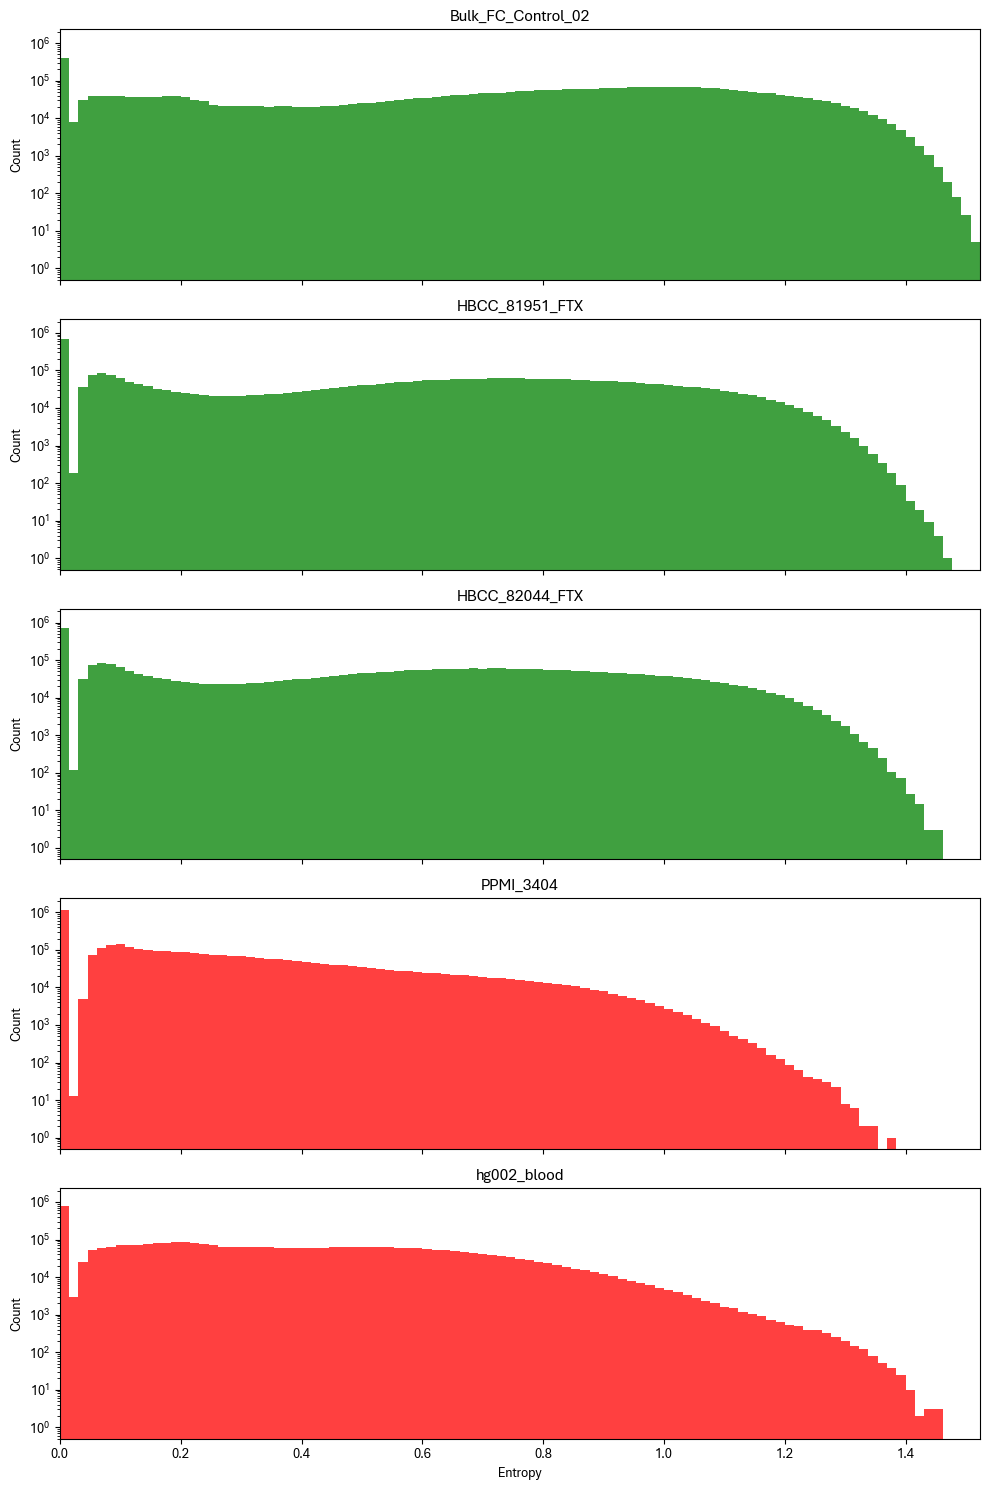

In [14]:
# Columns
brain_cols = df1.columns[3:6]   # first 3 samples
blood_cols = df1.columns[6:8]   # last 2 samples
all_cols = list(brain_cols) + list(blood_cols)

# Colors
colors = {col: "green" for col in brain_cols}
colors.update({col: "red" for col in blood_cols})

# Compute global x-axis limits
all_values = df1[all_cols].values.flatten()
xmin, xmax = np.nanmin(all_values), np.nanmax(all_values)

# Define bins globally so all histograms align
bins = np.linspace(xmin, xmax, 100)

# Compute global y-axis max
ymax = 0
hist_data = {}

for col in all_cols:
    vals = df1[col].dropna()
    counts, _ = np.histogram(vals, bins=bins)
    ymax = max(ymax, counts.max())
    hist_data[col] = vals

# Plot
fig, axes = plt.subplots(len(all_cols), 1, figsize=(10, 15), sharex=True, sharey=True)

quantiles = [0.25, 0.5, 0.75]

for ax, col in zip(axes, all_cols):
    vals = hist_data[col]
    
    sns.histplot(vals, bins=bins, ax=ax, color=colors[col], edgecolor=None)
    
    ax.set_yscale('log')
    ax.set_title(col)
    ax.set_xlim(xmin, xmax)

# Labels
axes[0].set_ylabel("Count")
for ax in axes:
    ax.set_xlabel("Entropy")

plt.tight_layout()
plt.show()

### Pairwise sample comparison

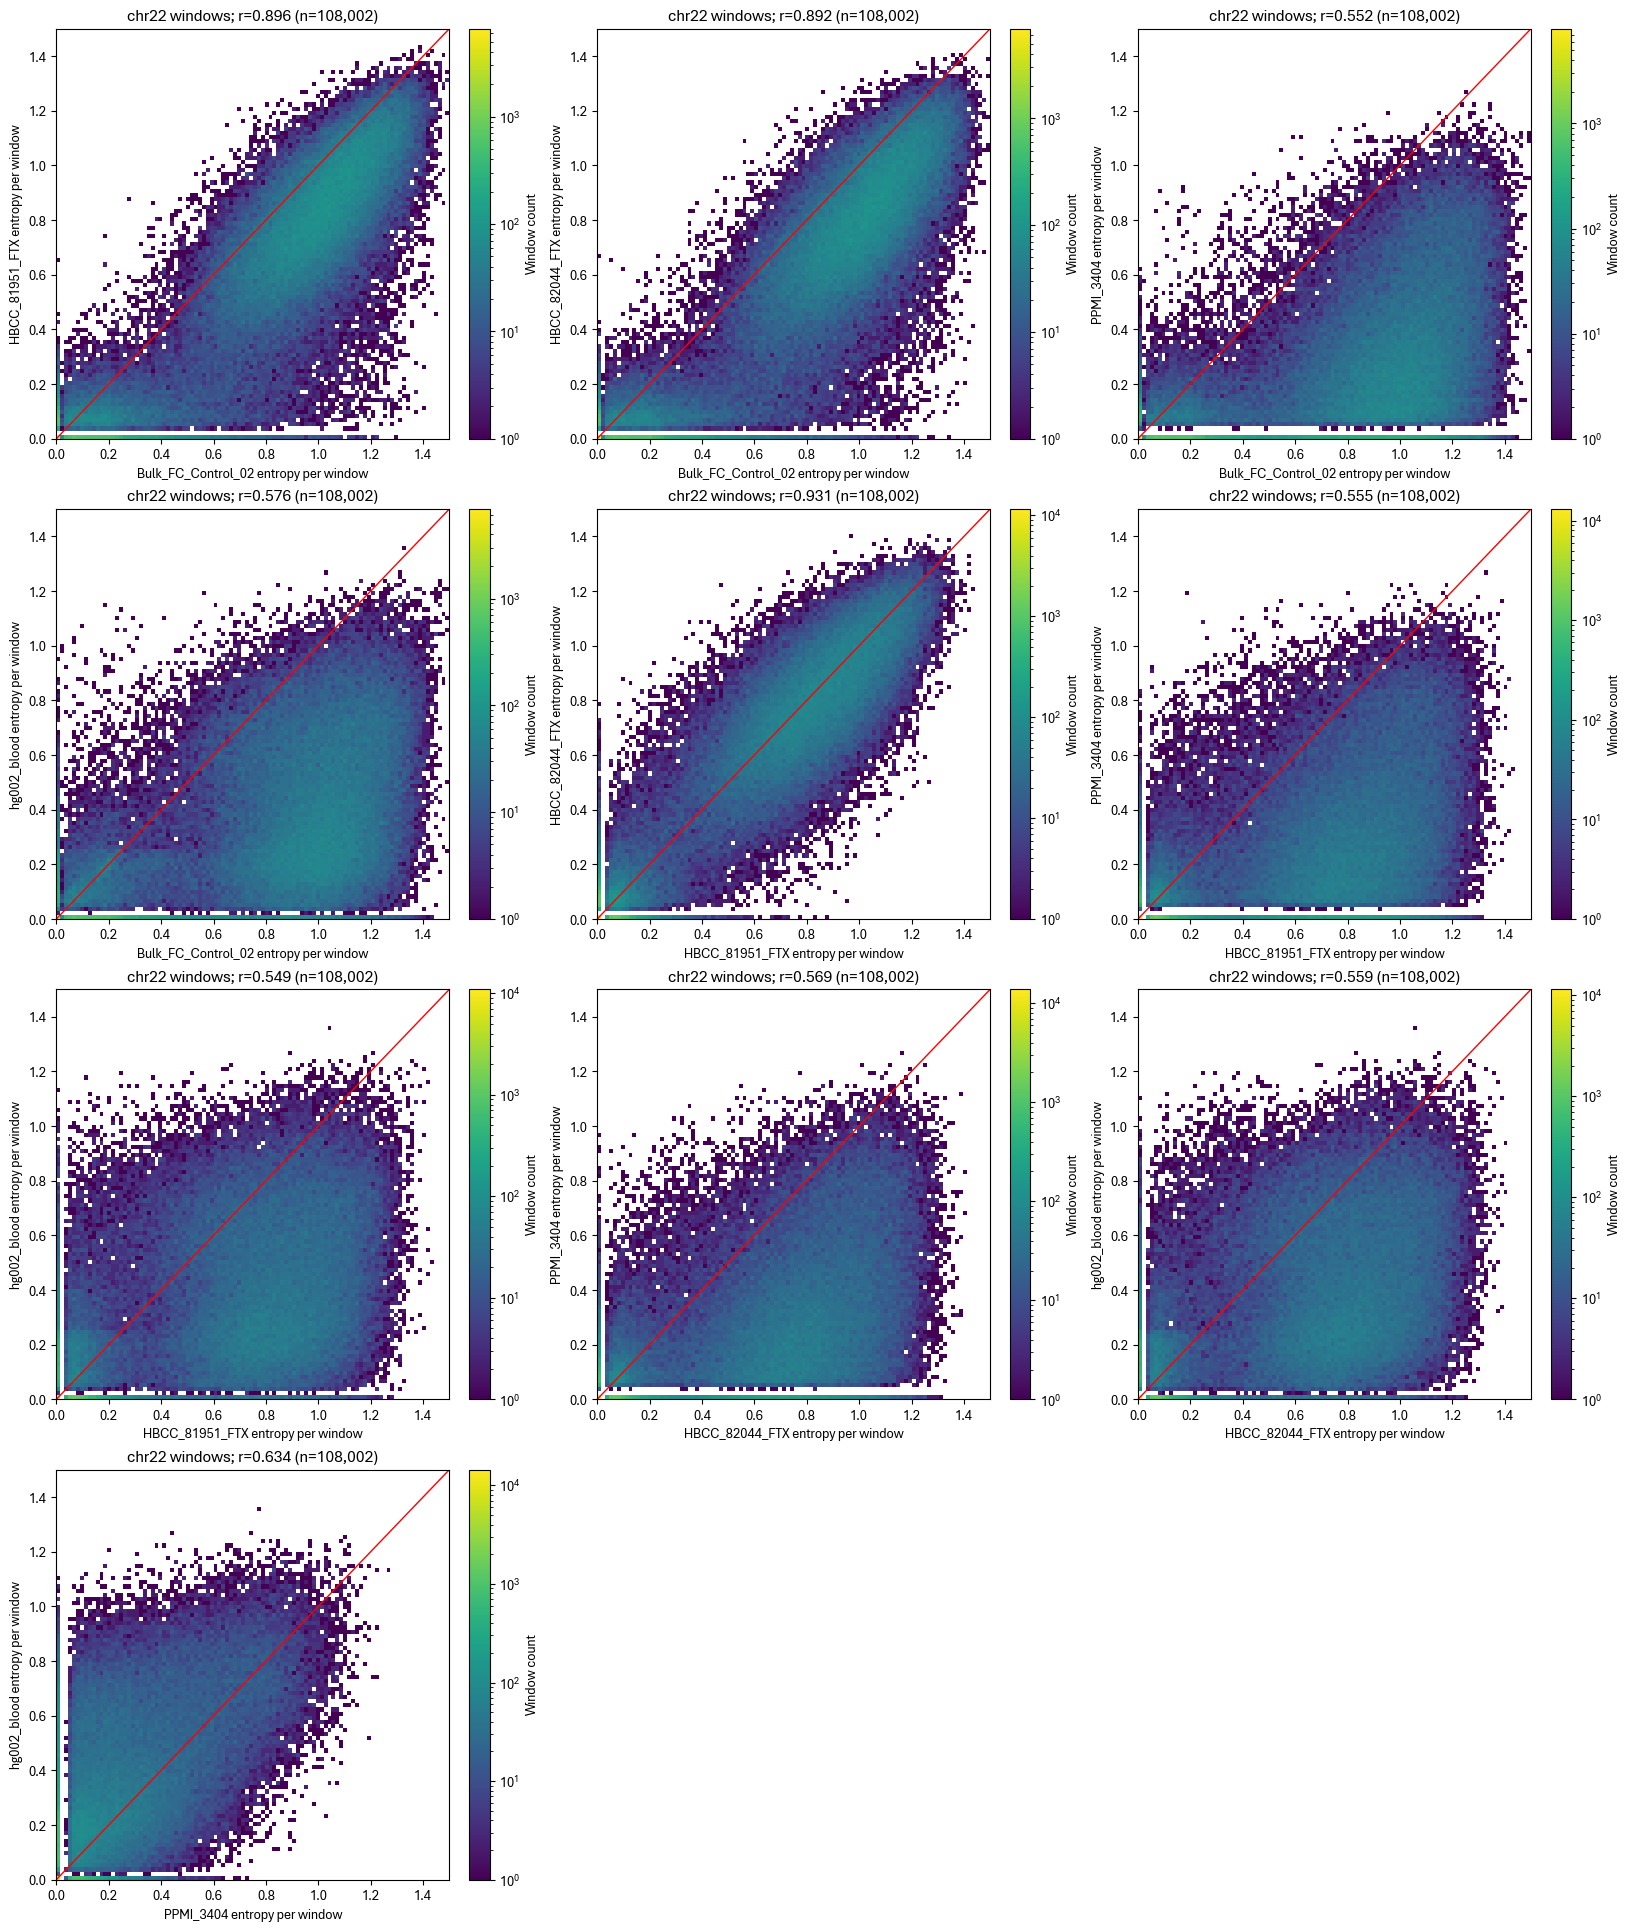

In [16]:
# ----------------------------
# 1) define sample columns
# ----------------------------
sample_cols = list(df1.columns[3:])   # the 5 sample columns

# ----------------------------
# 2) keep only chr22
# ----------------------------
df22 = df1.loc[df1["chrom"] == "chr22", ["chrom", "start", "end"] + sample_cols].copy()

# ----------------------------
# 3) all unique sample pairs
# ----------------------------
pairs = list(itertools.combinations(sample_cols, 2))   # 10 pairs total

# ----------------------------
# 4) use one common axis range across all plots
# ----------------------------
all_vals = df22[sample_cols].to_numpy().ravel()
all_vals = all_vals[np.isfinite(all_vals)]

vmin = all_vals.min()
vmax = all_vals.max()

# optional: force lower bound to 0 if you want all plots to start there
vmin = min(0, vmin)

# ----------------------------
# 5) plot settings
# ----------------------------
nbins = 100
n_pairs = len(pairs)

ncols = 3
nrows = math.ceil(n_pairs / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.4 * ncols, 4.8 * nrows),
    constrained_layout=True
)

axes = np.ravel(axes)

for ax, (xcol, ycol) in zip(axes, pairs):
    sub = df22[[xcol, ycol]].dropna()

    x = sub[xcol].to_numpy()
    y = sub[ycol].to_numpy()

    # Pearson correlation
    r = np.corrcoef(x, y)[0, 1]
    n = len(sub)

    # 2D histogram with log-scaled counts
    h = ax.hist2d(
        x,
        y,
        bins=nbins,
        range=[[vmin, vmax], [vmin, vmax]],
        norm=LogNorm(),
        cmap="viridis",
        cmin=1
    )

    # diagonal y=x
    ax.plot([vmin, vmax], [vmin, vmax], color="red", linewidth=1)

    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

    ax.set_xlabel(f"{xcol} entropy per window")
    ax.set_ylabel(f"{ycol} entropy per window")
    ax.set_title(f"chr22 windows; r={r:.3f} (n={n:,})")

    # colorbar for each panel
    cbar = fig.colorbar(h[3], ax=ax)
    cbar.set_label("Window count")

# turn off any unused axes
for ax in axes[len(pairs):]:
    ax.axis("off")

plt.show()

### Brain / Blood high-low entropy

In [4]:
brain_cols = df1.columns[3:6]
blood_cols = df1.columns[6:8]

#### 0.25 and 0.75

In [5]:
# high = top 25%, low = bottom 25% (tunable)
label = '25_75'
high_q = 0.75
low_q = 0.25

thresholds = {}

for col in brain_cols.tolist() + blood_cols.tolist():
    thresholds[col] = {
        "high": df1[col].quantile(high_q),
        "low": df1[col].quantile(low_q)
    }

print(label)
thresholds

25_75


{'Bulk_FC_Control_02': {'high': 1.0145572999999999, 'low': 0.28305465},
 'HBCC_81951_FTX': {'high': 0.82928847, 'low': 0.09857506},
 'HBCC_82044_FTX': {'high': 0.7978398200000001, 'low': 0.08750265},
 'PPMI_3404': {'high': 0.35449794, 'low': 0.0},
 'hg002_blood': {'high': 0.53669493, 'low': 0.0928081}}

In [11]:
# brain high
brain_high = np.logical_and.reduce([
    df1[col] >= thresholds[col]["high"] for col in brain_cols
])

blood_low = np.logical_and.reduce([
    df1[col] <= thresholds[col]["low"] for col in blood_cols
])

brain_high_blood_low = df1[brain_high & blood_low]

# blood high
brain_low = np.logical_and.reduce([
    df1[col] <= thresholds[col]["low"] for col in brain_cols
])

blood_high = np.logical_and.reduce([
    df1[col] >= thresholds[col]["high"] for col in blood_cols
])

brain_low_blood_high = df1[brain_low & blood_high]

print('Brain high, blood low:', brain_high_blood_low.shape[0])
print('Brain low, blood high:', brain_low_blood_high.shape[0])

Brain high, blood low: 3837
Brain low, blood high: 364


In [42]:
# make a new dataframe of regions
brain_high_blood_low['high_tissue'] = 'brain'
brain_low_blood_high['high_tissue'] = 'blood'

df2 = pd.concat([brain_high_blood_low, brain_low_blood_high]).sort_index()
df2 = df2[['chrom', 'start', 'end', 'high_tissue', 'Bulk_FC_Control_02', 'HBCC_81951_FTX',
       'HBCC_82044_FTX', 'PPMI_3404', 'hg002_blood']]

out_tsv = os.path.join(DIR1, 'tissue_entropy_regions_'+label+'.tsv')
out_bed = os.path.join(DIR1, 'tissue_entropy_regions_'+label+'.bed')

df2.to_csv(out_tsv, sep='\t', index=False)
df2[['chrom', 'start', 'end']].to_csv(out_bed, sep='\t', index=False, header=False)

/tmp/ipykernel_2678745/2914592245.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brain_high_blood_low['high_tissue'] = 'brain'
/tmp/ipykernel_2678745/2914592245.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brain_low_blood_high['high_tissue'] = 'blood'


In [15]:
region_dict = {'brain_high': brain_high,
              'brain_low': brain_low,
              'blood_high': blood_high,
              'blood_low': blood_low}

for region, rows in region_dict.items():
    out_tsv = os.path.join(DIR1, region+'_entropy_regions_'+label+'.tsv')
    out_bed = os.path.join(DIR1, region+'_entropy_regions_'+label+'.bed')

    print(region, rows.sum())
    
    df1[rows].to_csv(out_tsv, sep='\t', index=False)
    df1[rows][['chrom', 'start', 'end']].to_csv(out_bed, sep='\t', index=False, header=False)

brain_high 608375
brain_low 638761
blood_high 510744
blood_low 612504


#### 0.1 and 0.9

In [16]:
# high = top 10%, low = bottom 10% (tunable)
label = '10_90'
high_q = 0.9
low_q = 0.1

thresholds = {}

for col in brain_cols.tolist() + blood_cols.tolist():
    thresholds[col] = {
        "high": df1[col].quantile(high_q),
        "low": df1[col].quantile(low_q)
    }

print(label)
thresholds

10_90


{'Bulk_FC_Control_02': {'high': 1.1647462, 'low': 0.0},
 'HBCC_81951_FTX': {'high': 1.0097388, 'low': 0.0},
 'HBCC_82044_FTX': {'high': 0.9852308, 'low': 0.0},
 'PPMI_3404': {'high': 0.5847405, 'low': 0.0},
 'hg002_blood': {'high': 0.7070053, 'low': 0.0}}

In [17]:
# brain high
brain_high = np.logical_and.reduce([
    df1[col] >= thresholds[col]["high"] for col in brain_cols
])

blood_low = np.logical_and.reduce([
    df1[col] <= thresholds[col]["low"] for col in blood_cols
])

brain_high_blood_low = df1[brain_high & blood_low]

# blood high
brain_low = np.logical_and.reduce([
    df1[col] <= thresholds[col]["low"] for col in brain_cols
])

blood_high = np.logical_and.reduce([
    df1[col] >= thresholds[col]["high"] for col in blood_cols
])

brain_low_blood_high = df1[brain_low & blood_high]

print('Brain high, blood low:', brain_high_blood_low.shape[0])
print('Brain low, blood high:', brain_low_blood_high.shape[0])

Brain high, blood low: 317
Brain low, blood high: 2


In [45]:
# make a new dataframe of regions
brain_high_blood_low['high_tissue'] = 'brain'
brain_low_blood_high['high_tissue'] = 'blood'

df2 = pd.concat([brain_high_blood_low, brain_low_blood_high]).sort_index()
df2 = df2[['chrom', 'start', 'end', 'high_tissue', 'Bulk_FC_Control_02', 'HBCC_81951_FTX',
       'HBCC_82044_FTX', 'PPMI_3404', 'hg002_blood']]

out_tsv = os.path.join(DIR1, 'tissue_entropy_regions_'+label+'.tsv')
out_bed = os.path.join(DIR1, 'tissue_entropy_regions_'+label+'.bed')

df2.to_csv(out_tsv, sep='\t', index=False)
df2[['chrom', 'start', 'end']].to_csv(out_bed, sep='\t', index=False, header=False)

/tmp/ipykernel_2678745/2914592245.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brain_high_blood_low['high_tissue'] = 'brain'
/tmp/ipykernel_2678745/2914592245.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brain_low_blood_high['high_tissue'] = 'blood'


In [18]:
region_dict = {'brain_high': brain_high,
              'brain_low': brain_low,
              'blood_high': blood_high,
              'blood_low': blood_low}

for region, rows in region_dict.items():
    out_tsv = os.path.join(DIR1, region+'_entropy_regions_'+label+'.tsv')
    out_bed = os.path.join(DIR1, region+'_entropy_regions_'+label+'.bed')

    print(region, rows.sum())
    
    df1[rows].to_csv(out_tsv, sep='\t', index=False)
    df1[rows][['chrom', 'start', 'end']].to_csv(out_bed, sep='\t', index=False, header=False)

brain_high 173001
brain_low 173788
blood_high 169364
blood_low 516183
